In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 4070


# Task 1 — Dataset Inspection and Sanity Checks
## Task 1.1 Load and Inspect JSONL Files

**QUESTION 14: Load da-dev-questions.jsonl and da-dev-labels.jsonl. Report:**
- **The number of questions and labels.**
- **The set of keys present in a question record (print one example).**
- **The set of keys present in a label record (print one example).**


In [2]:
import json

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

questions = load_jsonl("./proj3_agent_data/share_data/da-dev-questions.jsonl")
labels = load_jsonl("./proj3_agent_data/share_data/da-dev-labels.jsonl")

print(f"Number of questions: {len(questions)}\nNumber of labels: {len(labels)}\n")

q_example = questions[0]
print(q_example, "\n")
print("\nKeys in a question record:")
print(q_example.keys(), "\n")
l_example = labels[0]
print(l_example)
print("\nKeys in a label record:")
print(l_example.keys())

Number of questions: 257
Number of labels: 257

{'id': 0, 'question': 'Calculate the mean fare paid by the passengers.', 'concepts': ['Summary Statistics'], 'constraints': "Calculate the mean fare using Python's built-in statistics module or appropriate statistical method in pandas. Rounding off the answer to two decimal places.", 'format': '@mean_fare[mean_fare_value] where "mean_fare_value" is a floating-point number rounded to two decimal places.', 'file_name': 'test_ave.csv', 'level': 'easy'} 


Keys in a question record:
dict_keys(['id', 'question', 'concepts', 'constraints', 'format', 'file_name', 'level']) 

{'id': 0, 'common_answers': [['mean_fare', '34.65']]}

Keys in a label record:
dict_keys(['id', 'common_answers'])


### Task 1.2 Inspect the Table References
**QUESTION 15: Pick 3 random question IDs. For each:**
- **Print the file name of the referenced CSV.**
- **Load the CSV with pandas and print df.shape, df.dtypes, and df.head(3).**
- **Print the corresponding question.**


In [3]:
import random
import pandas as pd
sampled_questions = random.sample(questions, 3)

for i, q in enumerate(sampled_questions, start=1):
    print(f"\n{'='*60}")
    print(f"Example {i}")
    
    qid = q.get("id")
    csv_file = q.get("file_name")
    question_text = q.get("question")

    print(f"Question ID: {qid}")
    print(f"CSV file: {csv_file}")

    prefix = "./proj3_agent_data/share_data/da-dev-tables/"
    df = pd.read_csv(prefix + csv_file)

    print("\nDataFrame shape:")
    print(df.shape)

    print("\nDataFrame dtypes:")
    print(df.dtypes)

    print("\nDataFrame head (first 3 rows):")
    display(df.head(3))

    print("\nQuestion:")
    print(question_text)


Example 1
Question ID: 656
CSV file: DES=+2006261.csv

DataFrame shape:
(329, 6)

DataFrame dtypes:
JDTDB                  float64
Calendar Date (TDB)     object
X                      float64
Y                      float64
Z                      float64
Unnamed: 5             float64
dtype: object

DataFrame head (first 3 rows):


,JDTDB,Calendar Date (TDB),X,Y,Z,Unnamed: 5
0,2.451215e+06,A.D. 1999-Feb-05 00:58:29.0000,-2.887479e+08,2.475795e+07,2.212686e+07,NaN
1,2.451216e+06,A.D. 1999-Feb-06 00:58:29.0000,-2.894466e+08,2.303593e+07,2.286679e+07,NaN
2,2.451217e+06,A.D. 1999-Feb-07 00:58:29.0000,-2.901336e+08,2.131300e+07,2.360580e+07,NaN



Question:
3. Perform an outlier analysis on the X-coordinate column using the Z-score method. Identify any outliers based on a threshold of 3 standard deviations from the mean. Then, remove the outliers from the dataset and calculate the new mean and standard deviation of the X-coordinate column.

Example 2
Question ID: 72
CSV file: microsoft.csv

DataFrame shape:
(251, 7)

DataFrame dtypes:
Unnamed: 0      int64
Date           object
Open          float64
High          float64
Low           float64
Close         float64
Volume          int64
dtype: object

DataFrame head (first 3 rows):


,Unnamed: 0,Date,Open,High,Low,Close,Volume
0,0,19-Jan-18,90.14,90.61,89.66,90.00,36875013
1,1,18-Jan-18,89.80,90.67,89.66,90.10,24159683
2,2,17-Jan-18,89.08,90.28,88.75,90.14,25621164



Question:
Check if the "Close" column adheres to a normal distribution.

Example 3
Question ID: 352
CSV file: test_x.csv

DataFrame shape:
(418, 8)

DataFrame dtypes:
Pclass        int64
Sex           int64
Age           int64
Fare          int64
Embarked      int64
Title         int64
IsAlone       int64
Age*Pclass    int64
dtype: object

DataFrame head (first 3 rows):


,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Pclass
0,3,0,2,0,2,1,1,6
1,3,1,2,0,0,3,0,6
2,2,0,3,1,2,1,1,6



Question:
Identify any outliers in the Fare column using the Z-score method.


## Task 1.3 Understand the Required Answer Format
**QUESTION 16: Find 2 examples where the required format contains multiple answer slots (e.g., two or more @name[value] fields). Explain:**
- **How the dataset represents multi-part answers in the labels.**
- **How you plan to evaluate such answers automatically**

#### Example 1: Question 71 
Question:
"Calculate the mean and standard deviation of the "Volume" column."

Answer Format: "@mean_volume[mean_volume]\n@std_dev_volume[std_dev_volume]\nwhere "mean_volume" and "std_dev_volume" are floating-point numbers rounded to 2 decimal places."

Labels: ['mean_volume', '22607406.19'], ['std_dev_volume', '8254791.71']

#### Example 2: Question 140
Question:
Question 3: Is there a correlation between the number of votes received by the Democratic and Republican parties? If so, is it a linear or nonlinear relationship?

Answer Format: "{ @correlation_coefficient[r_value] @p_value[p_value] @relationship_type[relationship_type] where "r_value" is a number between -1 and 1, rounded to three decimal places. where "p_value" is a number between 0 and 1, rounded to four decimal places. where "relationship_type" is a string that can either be "linear", "nonlinear", or "none" based on the conditions specified in the constraints."

Labels: ['correlation_coefficient', '0.828'], ['relationship_type', 'linear']


#### How the dataset represents multi-part answers in the labels.

The dataset represents multi-part answers by defining name-value pairs ['name', 'value'] for each field in the answer format. The answers are slotted into the correct spot in the answer format string specified by @name[value].

#### How you plan to evaluate such answers automatically

Evaluating multi-part answers automatically requires breaking down the problem into evaluating each individual part, making sure it meets all the requirements, and then assembling them together appropriately in the end. 

In [4]:
labels_by_id = {label["id"]: label for label in labels}
questions_by_id = {question["id"]: question for question in questions}
print(labels_by_id.get(71))
print(labels_by_id.get(140))

{'id': 71, 'common_answers': [['mean_volume', '22607406.19'], ['std_dev_volume', '8254791.71']]}
{'id': 140, 'common_answers': [['correlation_coefficient', '0.828'], ['relationship_type', 'linear']]}


## Task 1.4 Checking the subset
**QUESTION 17: Unfortunately, the model we are going to use is still not powerful enough to
solve all the tasks. Here we are selecting 10 sub-tasks that are proved to be solveable:
The selected IDs are: SELECTED IDS = [0, 5, 9, 10, 14, 18, 24, 25, 26, 55].**
- **Print out and check those tasks.**

In [63]:
SELECTED_IDS = [0, 5, 9, 10, 14, 18, 24, 25, 26, 55]
qset = {qid: questions_by_id[qid] for qid in SELECTED_IDS}
qset_labels = {qid: labels_by_id[qid] for qid in SELECTED_IDS}
qset

{0: {'id': 0,
  'question': 'Calculate the mean fare paid by the passengers.',
  'concepts': ['Summary Statistics'],
  'constraints': "Calculate the mean fare using Python's built-in statistics module or appropriate statistical method in pandas. Rounding off the answer to two decimal places.",
  'format': '@mean_fare[mean_fare_value] where "mean_fare_value" is a floating-point number rounded to two decimal places.',
  'file_name': 'test_ave.csv',
  'level': 'easy'},
 5: {'id': 5,
  'question': 'Generate a new feature called "FamilySize" by summing the "SibSp" and "Parch" columns. Then, calculate the Pearson correlation coefficient (r) between the "FamilySize" and "Fare" columns.',
  'concepts': ['Feature Engineering', 'Correlation Analysis'],
  'constraints': "Create a new column 'FamilySize' that is the sum of 'SibSp' and 'Parch' for each row.\nCalculate the Pearson correlation coefficient between 'FamilySize' and 'Fare'\nDo not perform any further data cleaning or preprocessing steps

# Task 2 — Model Loading and Structured Output: Make the Planner Parseable
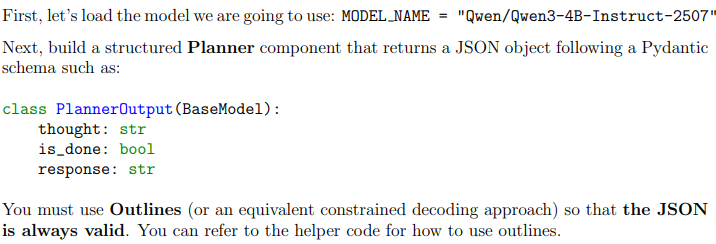

In [6]:
import torch
import outlines
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, device_map="auto", torch_dtype=torch.float16
)
model = outlines.from_transformers(hf_model, hf_tokenizer)
tokenizer = hf_tokenizer
print(f"Model loaded on {hf_model.device}")

C:\Users\katherinesohn\Documents\UCLA\ECE 219\Project 3 Part 2\venv.3.10.0\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 333.18it/s, Materializing param=model.norm.weight]


Model loaded on cuda:0


In [44]:
from typing import Type, Optional
from pydantic import BaseModel
import re
from dataclasses import dataclass as dc

@dc
class PlannerOutput(BaseModel):
    thought: str
    is_done: bool
    response: str

class Planner:
    """
    The reasoning module. Decides the next analysis step, or stops with the final formatted answer.
    """

    def __init__(self):
        self.extracted_values = {}

    def plan(self, problem, last_observation = None):
        """
        Construct the Planner prompt for a single ReAct step.
        """
        question = problem["question"]
        constraints = problem["constraints"]
        ans_format = problem["format"]
        file_name = "./proj3_agent_data/share_data/da-dev-tables/" + problem["file_name"]

        prompt = f"""
You are the Planner in a ReAct-style data analysis agent. Write the plan to answer the question, or stop with the final formatted
answer.

You must output a JSON object with the following fields:
- thought: brief reasoning about what to do next
- is_done: true if the final answer can be produced now, false otherwise
- response:
    - if is_done = false: a single, concrete instruction for the Coder
    - if is_done = true: the final answer formatted exactly as specified

Rules:
- Do NOT write Python code.
- Do NOT include explanations outside the JSON object.

Question:
{question}

Constraints:
{constraints}

Final output format:
{ans_format}

CSV file to use:
{file_name}

Stuff we know so far: 
{self.extracted_values}
Include info about these extracted values if it will help plan the code. 

When is_done = true, the final answer MUST follow the final output format specified above, with @name[value] for each answer component. 
""".strip()

        # Include last observation if available
        if last_observation:
            obs_summary = (
                f"Last observation:\n"
                f"  New extracted values: {last_observation.extracted_values}\n"
                f"  Warnings: {last_observation.warnings}\n"
                f"  Error category: {last_observation.error_category}\n"
                f"  Next step hint: {last_observation.next_step_hint}"
            )
            prompt += "\n\n" + obs_summary
            self.extracted_values.update(last_observation.extracted_values)

        return prompt, generate(messages=[{"role": "user", "content": prompt}], response_format=PlannerOutput)

In [8]:
def generate(
    messages: list[dict],
    response_format: Type[BaseModel],
    max_new_tokens: int = 4096,
    temperature: float = 0.6,
    top_p: float = 0.95,
) -> "BaseModel":
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    result = model(prompt, response_format, max_new_tokens=max_new_tokens)
    return response_format.model_validate_json(result)

In [73]:
pln = Planner()
_, result = pln.plan({"question": "What is 12 * 13?", "constraints": None, "format": None, "file_name": ""})
print(f"Type:      {type(result).__name__}")
print(f"Thought: {result.thought}")
print(f"Is Done?:    {result.is_done}")
print(f"Response:    {result.response}")

Type:      PlannerOutput
Thought: The question is a simple arithmetic multiplication that can be solved directly.
Is Done?:    True
Response:    value: 156


**QUESTION 18: Demonstrate (with 5 different prompts) that your planner always returns valid
JSON that parses into your Pydantic model without try/except fallbacks. Include at least one case
where the planner decides it is done (is done=true).**

In [10]:
prompts = [
    {"question": "What is 12 * 13?", "constraints": None, "format": None, "file_name": ""},
    {"question": "What will the stock market look like tomorrow?", "constraints": None, "format": None, "file_name": ""},
    {"question": "Perform comprehensive data preprocessing for the given dataset.", "constraints": None, "format": None, "file_name": ""},
    {"question": "I like pink.", "constraints": None, "format": None, "file_name": ""},
    {"question": "Check if all required project tasks are complete and report final status.", "constraints": None, "format": None, "file_name": ""}
]

planner = Planner()

for i, prompt in enumerate(prompts, 1):
    _, output = planner.plan(prompt)
    print(f"Prompt {i}:")
    print(prompt["question"])
    print(output.model_dump_json(), "\n")

Prompt 1:
What is 12 * 13?
{"thought":"The question is a simple arithmetic multiplication that can be solved directly.","is_done":true,"response":"156"} 

Prompt 2:
What will the stock market look like tomorrow?
{"thought":"The stock market's future state cannot be predicted from current data without forecasting models or real-time market feeds, which are not available in the provided dataset. Therefore, no actionable plan can be formed to determine tomorrow's stock market outlook.","is_done":true,"response":"The stock market's future state cannot be determined with the available data."} 

Prompt 3:
Perform comprehensive data preprocessing for the given dataset.
{"thought":"The question asks for comprehensive data preprocessing, which involves steps like handling missing values, removing duplicates, normalizing data, and ensuring data types are correct. However, no specific dataset or file details have been provided yet. To proceed, I need to identify the dataset to be preprocessed.","

**QUESTION 19: Explain in a few sentences why structured output is useful for large-scale data mining pipelines.**

Structured output is useful for large-scale data mining pipelines because with large scale, the output of steps of the pipeline can vary wildy in structure, organization, and size. By providing a structure to adhere to, we can more easily automate such a pipeline by making the output at each step more predicatable, so that we can write predictable steps to process and progress the task. This enabes more consistent and robust automation, as well as a well-defined modular structure. 

In [53]:
@dc
class CoderOutput(BaseModel):
    code: str
        
class Coder:
    """
    Writes code based on the planner output. 
    """

    def __init__(self):
        pass

    def code(self, plan: Type[PlannerOutput], problem):
        """
        Construct the prompt for the Coder.
        """
        constraints = problem["constraints"]
        file_name = "./proj3_agent_data/share_data/da-dev-tables/" + problem["file_name"]
        
        prompt = f"""
Write ONLY valid, executable Python that follows the instruction. 
Instruction:
{plan.response}

In case it's not in the instruction, here is the file path: {file_name}

- Use print(...) for all outputs
- DO NOT not print out full columns or tolist()s.  
- Do not rely on implicit notebook display.
- NEVER output natural language, explanations, or error messages directly
- be careful with indentation.
- DO NOT reload CSV files unless explicitly instructed. Instead, check for existing `df` from previous load.
"""
        return prompt, generate(messages=[{"role": "user", "content": prompt}], response_format=CoderOutput)

In [46]:
import io
import sys
import traceback
class Executor:
    """Executes Python code with a persistent namespace across calls.

    The namespace is shared between runs, so variables defined in step 1
    are available in step 2, etc.  Common libraries are pre-imported.
    """

    def __init__(self):
        self.namespace = {"__builtins__": __builtins__}
        # Pre-import libraries the coder will likely use
        exec(
            "import pandas as pd\nimport numpy as np\n"
            "from scipy import stats\nfrom sklearn import *\n",
            self.namespace,
        )

    def run(self, code: str, timeout: int = 30) -> str:
        """Execute code and return captured stdout/stderr."""
        stdout_buf = io.StringIO()
        stderr_buf = io.StringIO()
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = stdout_buf, stderr_buf

        # remove ```py formatting if present
        code = re.sub(r"^```[a-zA-Z]*\n?", "", code.strip())
        code = re.sub(r"\n?```$", "", code.strip())
        
        try:
            exec(code, self.namespace)
        except Exception:
            traceback.print_exc(file=stderr_buf)
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

        stdout = stdout_buf.getvalue().strip()
        stderr = stderr_buf.getvalue().strip()

        if stderr:
            return f"[STDOUT]\n{stdout}\n\n[ERROR]\n{stderr}" if stdout else f"[ERROR]\n{stderr}"
        return stdout if stdout else "(no output)"

    def reset(self):
        """Clear state for a new task."""
        self.__init__()

In [55]:
from typing import Dict, List, Optional, Union
from pydantic import BaseModel
from dataclasses import dataclass as dc

@dc
class ObserverOutput(BaseModel):
    extracted_values: Dict[str, Union[str, int, float]]
    warnings: List[str]
    error_category: Optional[str]
    next_step_hint: Optional[str]

class Observer:
    """
    The observer module. Converts raw tool output into a concise, task relevant observation that the planner can reliably use.
    """

    def __init__(self):
        pass
        
    def observe(self, executor_output, planner_output):
        """
        Construct the prompt for the Observer
        """
        
        prompt = f"""
This step was: {planner_output.response}
Executor output: {executor_output}

Produce a JSON object:
- extracted_values: map of requested values (look for these in the executor output)
- warnings: any relevant messages
- error_category: string (include if an error occurred)
- next_step_hint: string (optional)
- if you can't guess the name of an extracted value, name it something generic. 
"""
        return prompt, generate(messages=[{"role": "user", "content": prompt}], response_format=ObserverOutput)

In [14]:
class Agent:
    def __init__(self, model, max_steps = 5):
        self.planner = Planner()
        self.coder = Coder()
        self.executor = Executor()
        self.observer = Observer()
        
        self.max_steps = max_steps
        self.model = model

        self.history = []
        
    def solve(self, problem):
        print(problem["question"])
        print("="*60)

        last_observation = None
        for step in range(self.max_steps): 
            planner_prompt, planner_output = self.planner.plan(problem, last_observation)
            if planner_output.is_done:
                print(planner_output)
                print("="*60)
                self.history.append((planner_output.response, None, None, None))
                return planner_output.response, self.history
            
            # print(planner_prompt)
            # print("="*60)
            print(planner_output)
            print("="*60)
            
            coder_prompt, coder_output = self.coder.code(planner_output, problem)
            
            # print(coder_prompt)
            # print("="*60)
            print(coder_output)
            print("="*60)
            
            executor_output = self.executor.run(coder_output.code)
            
            print(executor_output)
            print("="*60)
    
            observer_prompt, observer_output = self.observer.observe(executor_output, planner_output)
            last_observation = observer_output
            
            print(observer_prompt)
            print("="*60)
            print(observer_output)
            print("="*60)

            self.history.append((planner_output.response, coder_output.code, executor_output, observer_output))
    
        return f"Couldn't solve in {self.max_steps} steps.", self.history

In [ ]:
agent = Agent(model)
answer, history = agent.solve(qset[0])

In [16]:
def check_output(pred: str, qid: int,) -> bool:
    """
    pred: model output string, e.g. "@mean_fare[34.65]"
    qid: question ID
    """
    # parse prediction
    slots = dict(re.findall(r"@(\w+)\[([^\]]+)\]", pred))
    
    # get gold answers
    label = labels_by_id.get(qid)
    if label is None:
        return False
    
    gold_list = label.get("common_answers", [])
    # convert to dict
    gold = {k: v for k, v in gold_list}

    # slot names must match
    if set(slots.keys()) != set(gold.keys()):
        return False
    
    # check values
    for k in gold:
        if slots[k].strip() != gold[k]:
            return False

    return True

In [ ]:
results = {}

for qid in SELECTED_IDS:
    agent = Agent(model)
    answer, history = agent.solve(qset[qid])
    
    is_correct = check_output(answer, qid)
    
    res = {
        "answer": answer,
        "history": history,
        "correct": is_correct
    }
    print(res["answer"], res["correct"])
    results[qid] = res

for qid, res in results.items():
    print(f"QID {qid}: correct={res['correct']}, answer={res['answer']}")

In [69]:
def print_history(history, indent=2):
    for step, (planner, code, executor, observer) in enumerate(history, start=1):
        print(f"{' ' * indent}Step {step}")
        print(f"{' ' * indent}  [Planner]")
        print(f"{' ' * indent}    {planner}")

        print(f"{' ' * indent}  [Coder]")
        if code:
            for line in code.splitlines():
                print(f"{' ' * indent}    {line}")
        else:
            print(f"{' ' * indent}    <empty>")

        print(f"{' ' * indent}  [Executor]")
        print(f"{' ' * indent}    {executor}")

        print(f"{' ' * indent}  [Observer]")
        print(f"{' ' * indent}    {observer}")
        print()

In [72]:
num_correct = sum(res["correct"] for res in results.values())
total = len(results)
accuracy = num_correct / total if total > 0 else 0.0

print(f"\nOverall accuracy: {accuracy:.2f} ({num_correct}/{total})")

for qid, res in results.items():
    print(f"\n===== QID {qid} =====")
    print(f"Correct: {res['correct']}")
    print("History:")
    print_history(res["history"])


Overall accuracy: 0.90 (9/10)

===== QID 0 =====
Correct: True
History:
  Step 1
    [Planner]
      Load the CSV file ./proj3_agent_data/share_data/da-dev-tables/test_ave.csv and extract the 'fare' column.
    [Coder]
      ```py
      import pandas as pd
      
      df = pd.read_csv('./proj3_agent_data/share_data/da-dev-tables/test_ave.csv')
      print(df['fare'])
      ```
    [Executor]
      [ERROR]
Traceback (most recent call last):
  File "C:\Users\katherinesohn\Documents\UCLA\ECE 219\Project 3 Part 2\venv.3.10.0\lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._l